# **Penguin Species Classification using Support Vector Machines (Kernel Comparison & Hyperparameter Tuning)**

## **High Level Workflow:**
1. Load dataset
2. Drop irrelevant columns
3. Handle missing values
4. Encode categorical variables
5. Train-test split
6. Scale numerical features
7. Train SVM (linear kernel)
8. Train SVM (RBF kernel)
9. Hyperparameter tuning (GridSearchCV)
10. Evaluate & compare results

In [90]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [91]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/penguins_lter.csv")
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [92]:
# Print the last 5 rows
df.tail()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN
343,PAL0910,124,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A2,Yes,11/22/09,49.9,16.1,213.0,5400.0,MALE,8.36390,-26.15531,NaN


In [93]:
# Print the shape of the dataframe
df.shape

(344, 17)

In [94]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [95]:
# Data type of the attributes of the dataframe
df.dtypes

,0
studyName,object
Sample Number,int64
Species,object
Region,object
Island,object
Stage,object
Individual ID,object
Clutch Completion,object
Date Egg,object
Culmen Length (mm),float64


In [96]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [97]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [98]:
df.keys()

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [99]:
df.nunique()

,0
studyName,3
Sample Number,152
Species,3
Region,1
Island,3
Stage,1
Individual ID,190
Clutch Completion,2
Date Egg,50
Culmen Length (mm),164


In [100]:
# Drop unnecessary columns
df = df.drop(['studyName', 'Sample Number', 'Region', 'Stage', 'Individual ID', 'Clutch Completion',
              'Date Egg', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'], axis=1)
df.head()

,Species,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie Penguin (Pygoscelis adeliae),Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin (Pygoscelis adeliae),Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [101]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [102]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
Species,0,0.000000
Island,0,0.000000
Culmen Length (mm),2,0.581395
Culmen Depth (mm),2,0.581395
Flipper Length (mm),2,0.581395
Body Mass (g),2,0.581395
Sex,10,2.906977


In [103]:
# Drop the missing values since the proportion of missing values is small
df.dropna(inplace=True)
print("Dataframe shape: ", df.shape)

Dataframe shape:  (334, 7)


In [104]:
df['Species'].value_counts()

,count
Species,
Adelie Penguin (Pygoscelis adeliae),146
Gentoo penguin (Pygoscelis papua),120
Chinstrap penguin (Pygoscelis antarctica),68


In [105]:
df['Species'] = df['Species'].replace({'Adelie Penguin (Pygoscelis adeliae)': 'Adelie', 'Gentoo penguin (Pygoscelis papua)': 'Gentoo',
                                       'Chinstrap penguin (Pygoscelis antarctica)': 'Chinstrap'})

# **Data Visualization:**

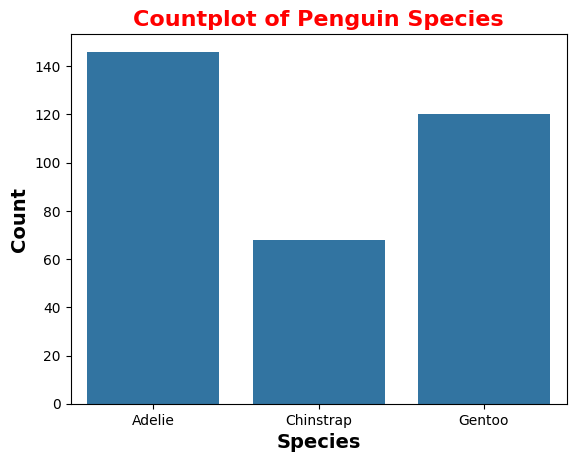

In [106]:
# Countplot of Penguin Species
sns.countplot(x = 'Species', data = df)
plt.title("Countplot of Penguin Species", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Count", fontsize = 14, fontweight = 'bold')
plt.show()

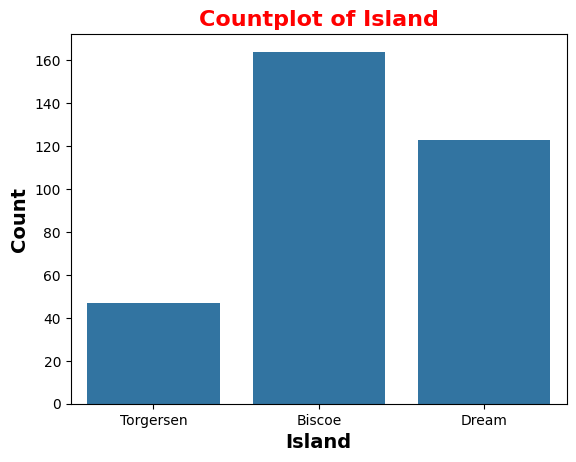

In [107]:
# Countplot of Island
sns.countplot(x = 'Island', data = df)
plt.title("Countplot of Island", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Island", fontsize = 14, fontweight = 'bold')
plt.ylabel("Count", fontsize = 14, fontweight = 'bold')
plt.show()

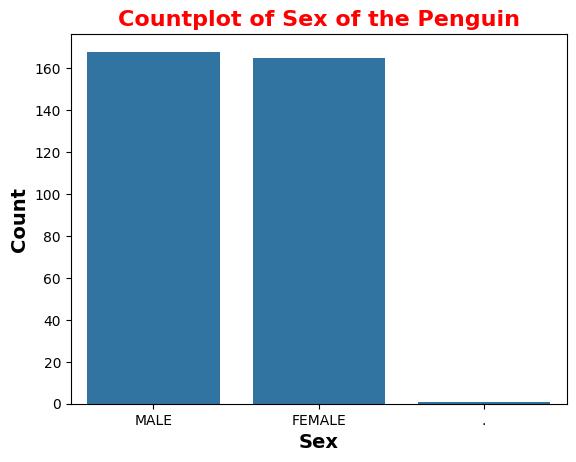

In [108]:
# Countplot of Sex of the Penguin
sns.countplot(x = 'Sex', data = df)
plt.title("Countplot of Sex of the Penguin", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Sex", fontsize = 14, fontweight = 'bold')
plt.ylabel("Count", fontsize = 14, fontweight = 'bold')
plt.show()

In [109]:
df['Sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [110]:
df['Sex'] = df['Sex'].replace('.', np.nan)
df.dropna(inplace = True)

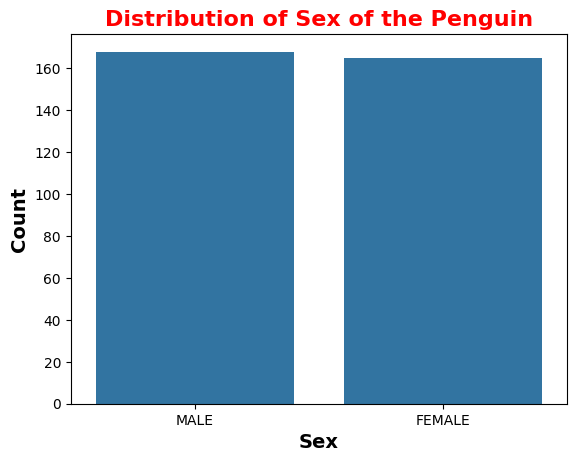

In [111]:
# Countplot of distribution of Sex of the Penguin
sns.countplot(x = 'Sex', data = df)
plt.title("Distribution of Sex of the Penguin", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Sex", fontsize = 14, fontweight = 'bold')
plt.ylabel("Count", fontsize = 14, fontweight = 'bold')
plt.show()

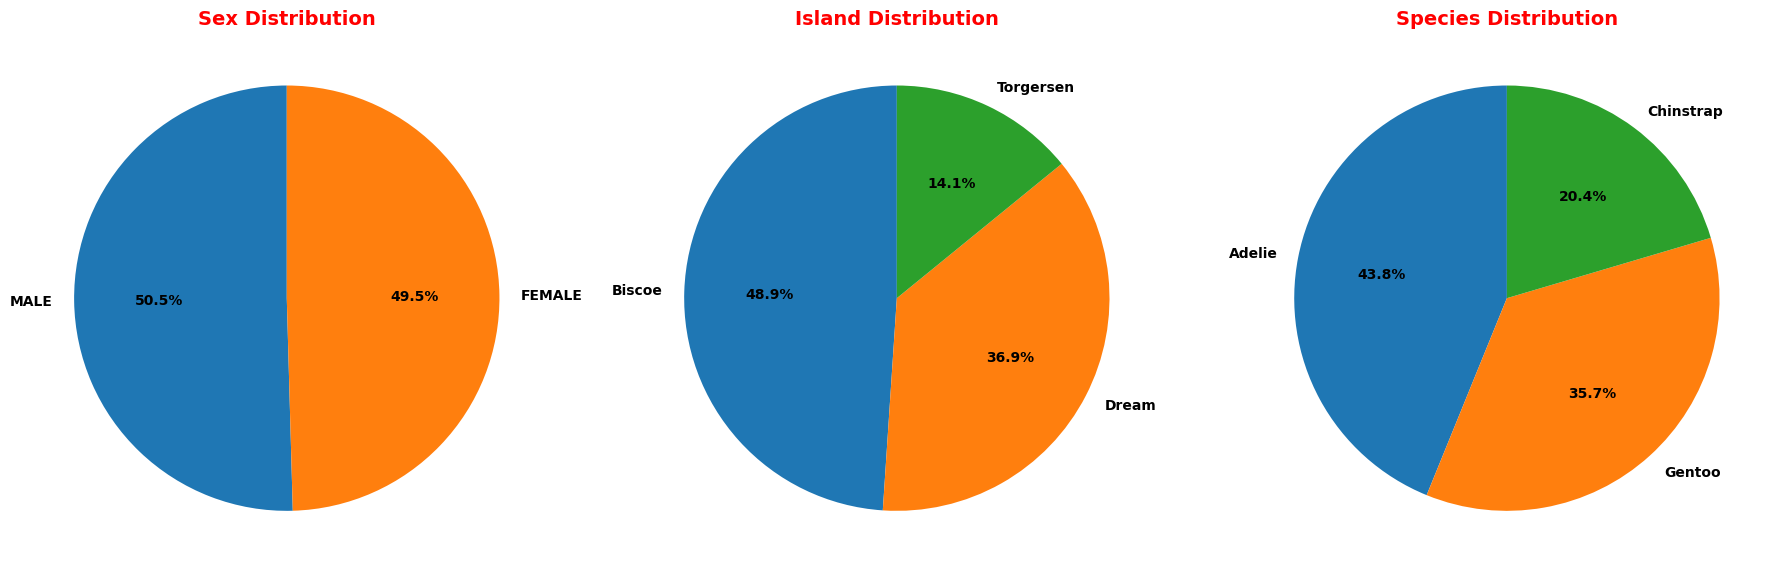

In [112]:
# Piechart of distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sex
axes[0].pie(df['Sex'].value_counts(), labels=df['Sex'].value_counts().index, autopct='%1.1f%%', startangle=90,
            textprops = {'fontsize': 10, 'fontweight': 'bold'})
axes[0].set_title('Sex Distribution', fontsize = 14, fontweight = 'bold', color = 'red')

# Island
axes[1].pie(df['Island'].value_counts(), labels=df['Island'].value_counts().index, autopct='%1.1f%%', startangle=90,
            textprops = {'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Island Distribution', fontsize = 14, fontweight = 'bold', color = 'red')

# Species
axes[2].pie(df['Species'].value_counts(), labels=df['Species'].value_counts().index, autopct='%1.1f%%', startangle=90,
            textprops = {'fontsize': 10, 'fontweight': 'bold'})
axes[2].set_title('Species Distribution', fontsize = 14, fontweight = 'bold', color = 'red')

plt.tight_layout()
plt.show()

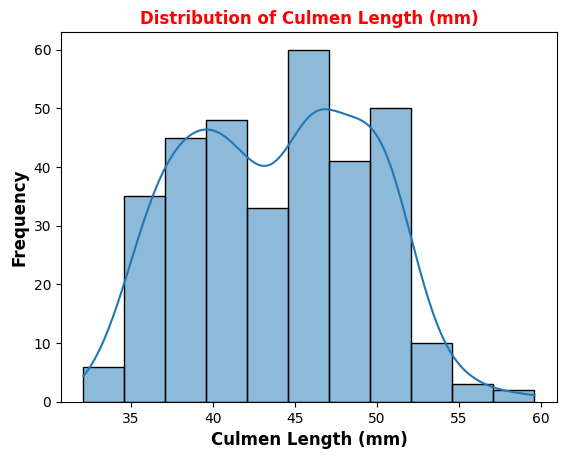

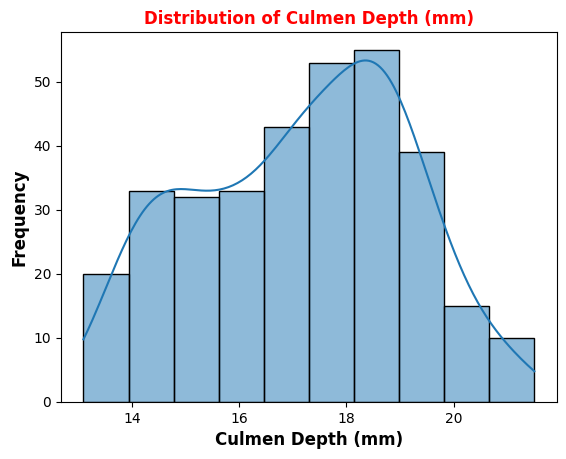

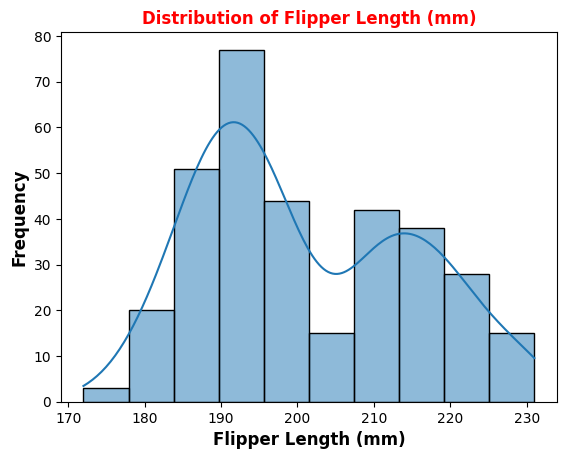

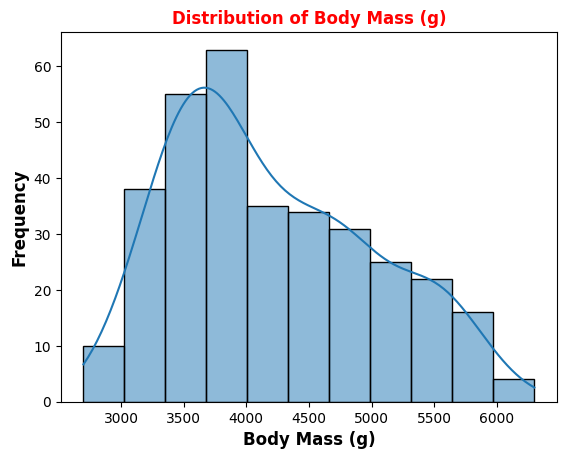

In [113]:
num_cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for col in num_cols:
    sns.histplot(df[col], kde = True)
    plt.title(f"Distribution of {col}", fontsize = 12, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 12, fontweight = 'bold')
    plt.ylabel("Frequency", fontsize = 12, fontweight = 'bold')
    plt.show()

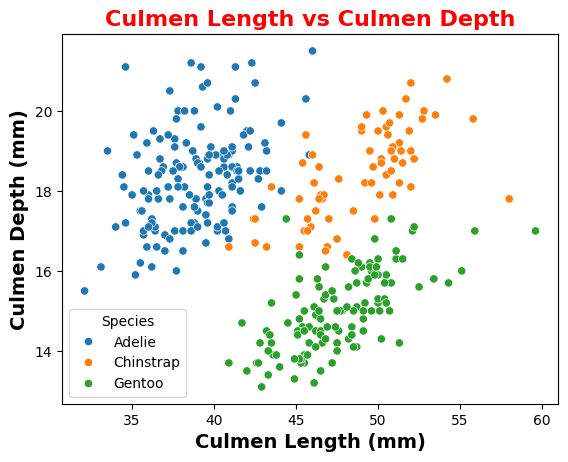

In [114]:
# Scatterplot of Culmen Length vs Culmen Depth
sns.scatterplot(x = "Culmen Length (mm)", y = "Culmen Depth (mm)", data = df, hue = "Species")
plt.title("Culmen Length vs Culmen Depth", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Culmen Length (mm)", fontsize = 14, fontweight = 'bold')
plt.ylabel("Culmen Depth (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

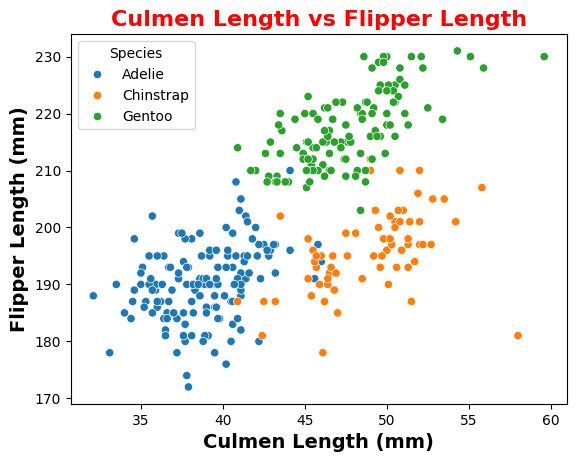

In [115]:
# Scatterplot of Culmen Length vs Flipper Length
sns.scatterplot(x = "Culmen Length (mm)", y = "Flipper Length (mm)", data = df, hue = "Species")
plt.title("Culmen Length vs Flipper Length", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Culmen Length (mm)", fontsize = 14, fontweight = 'bold')
plt.ylabel("Flipper Length (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

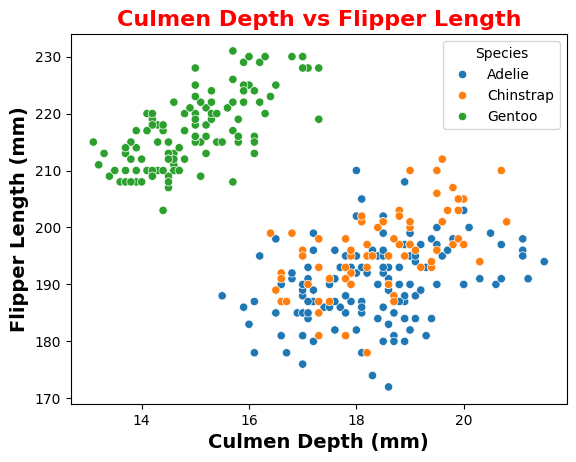

In [116]:
# Scatterplot of Culmen Depth vs Flipper Length
sns.scatterplot(x = "Culmen Depth (mm)", y = "Flipper Length (mm)", data = df, hue = "Species")
plt.title("Culmen Depth vs Flipper Length", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Culmen Depth (mm)", fontsize = 14, fontweight = 'bold')
plt.ylabel("Flipper Length (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

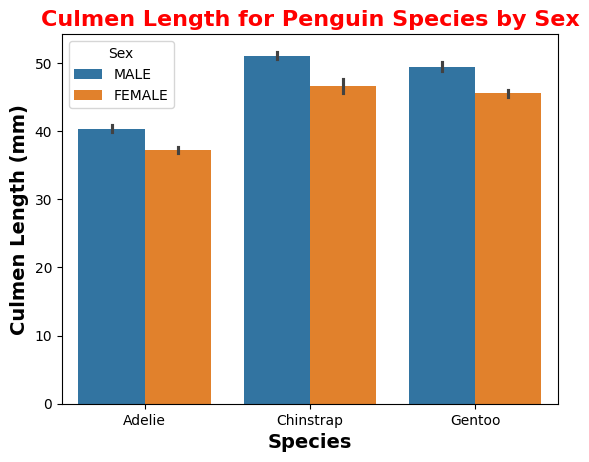

In [117]:
# Barplot of Culmen Length for 3 Penguin Species by Sex
sns.barplot(x = "Species", y = "Culmen Length (mm)", data = df, hue = "Sex")
plt.title("Culmen Length for Penguin Species by Sex", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Culmen Length (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

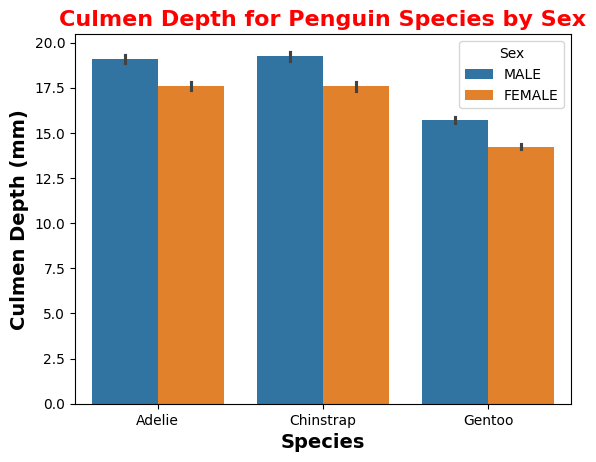

In [118]:
# Barplot of Culmen Depth for 3 Penguin Species by Sex
sns.barplot(x = "Species", y = "Culmen Depth (mm)", data = df, hue = "Sex")
plt.title("Culmen Depth for Penguin Species by Sex", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Culmen Depth (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

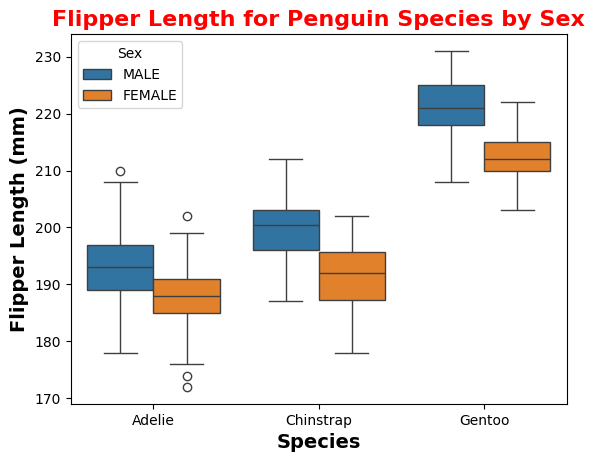

In [119]:
# Boxplot of Flipper Length for 3 Penguin Species by Sex
sns.boxplot(x = "Species", y = "Flipper Length (mm)", data = df, hue = "Sex")
plt.title("Flipper Length for Penguin Species by Sex", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Flipper Length (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

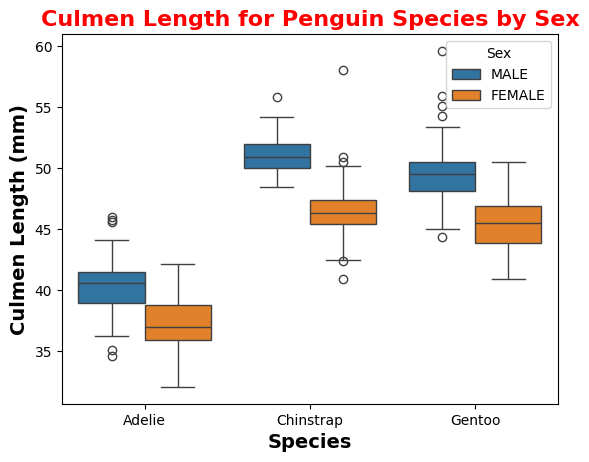

In [120]:
# Boxplot of Culmen Length for 3 Penguin Species by Sex
sns.boxplot(x = "Species", y = "Culmen Length (mm)", data = df, hue = "Sex")
plt.title("Culmen Length for Penguin Species by Sex", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Culmen Length (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

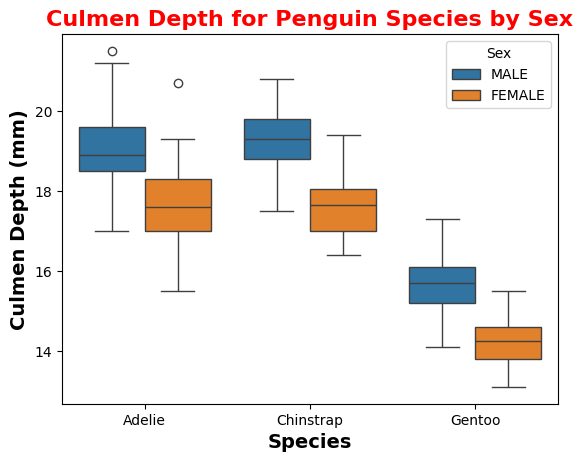

In [121]:
# Boxplot of Culmen Depth for 3 Penguin Species by Sex
sns.boxplot(x = "Species", y = "Culmen Depth (mm)", data = df, hue = "Sex")
plt.title("Culmen Depth for Penguin Species by Sex", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Species", fontsize = 14, fontweight = 'bold')
plt.ylabel("Culmen Depth (mm)", fontsize = 14, fontweight = 'bold')
plt.show()

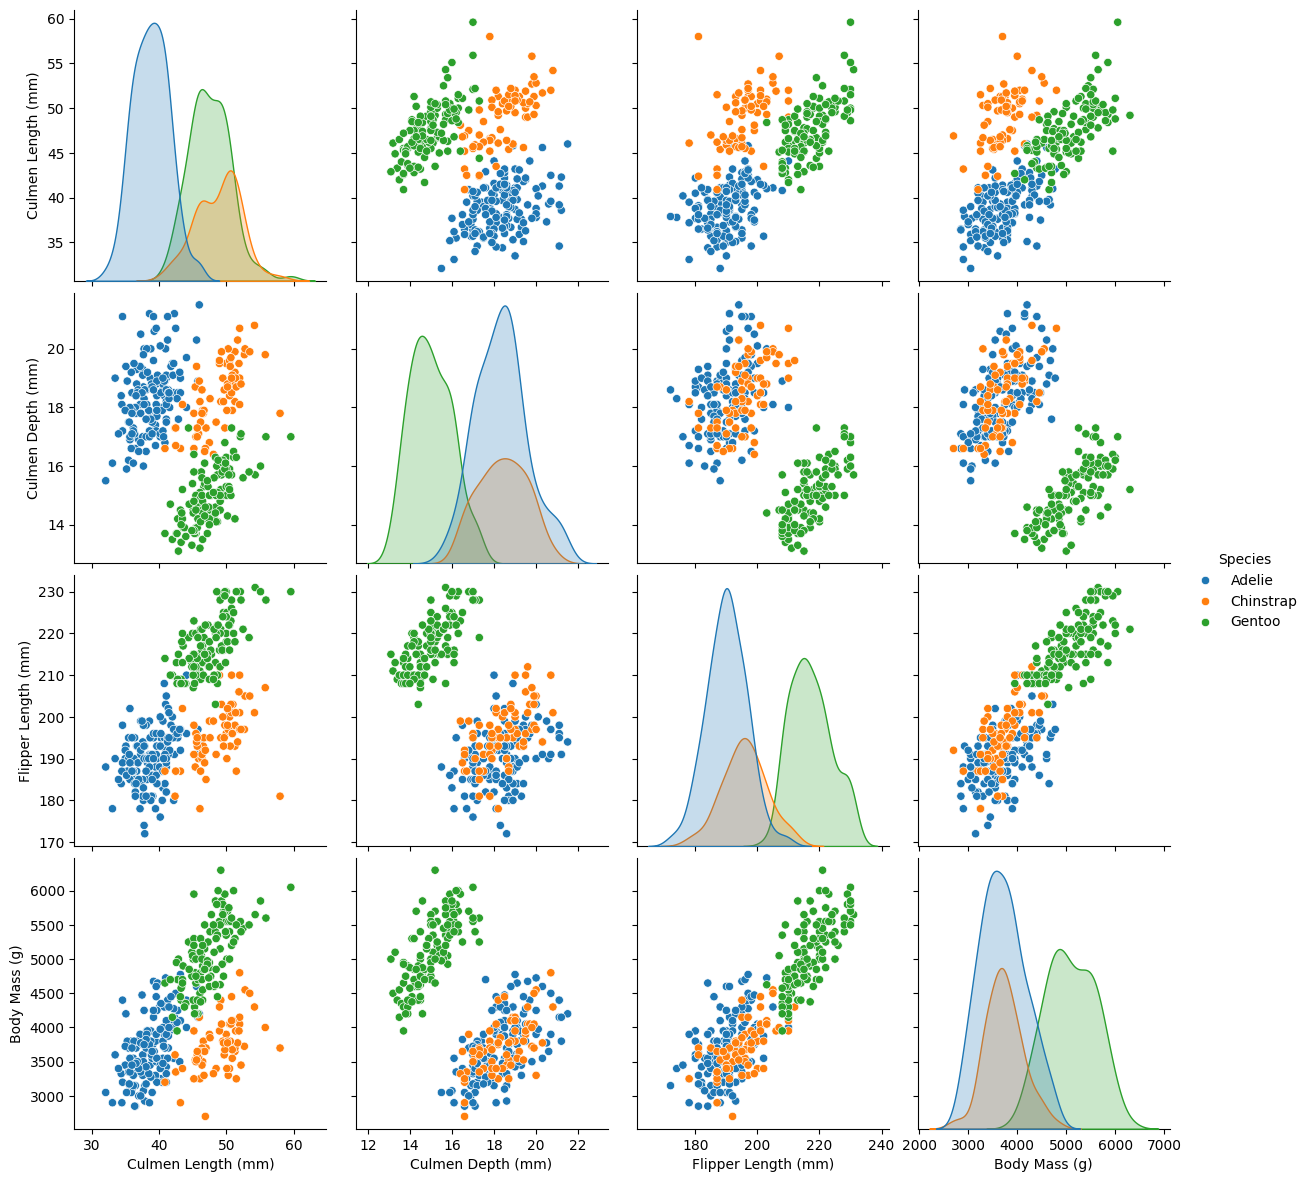

In [122]:
# Pairplot
sns.pairplot(df, hue = "Species", height = 3)

<Axes: >

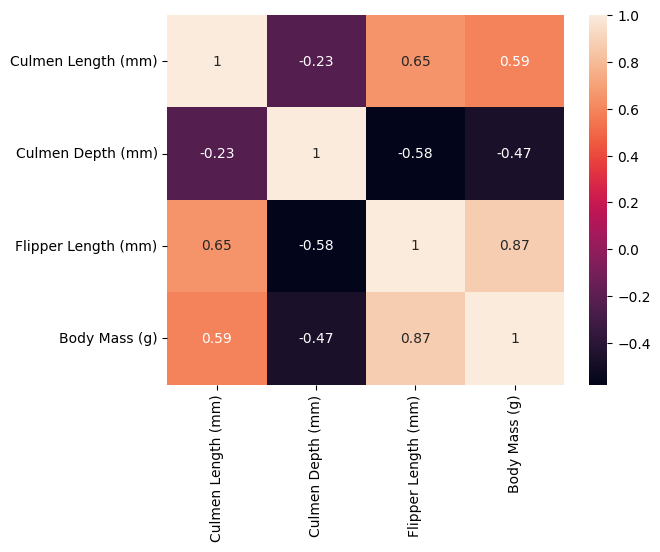

In [123]:
# Heatmap of num_cols
sns.heatmap(df[num_cols].corr(), annot = True)

# **SVM Model:**

In [124]:
X = df.drop('Species', axis = 1)
y = df['Species']

# Encoding categorical variables
X = pd.get_dummies(X, columns = ['Island', 'Sex'], drop_first = True)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Species'])

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **SVM (Linear Kernel):**

The linear kernel is the simplest kernel and is used for linearly separable data. It computes the dot product between the feature vectors of the input data points.

In [125]:
# Train SVM (Linear kernel with tuning)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

parameters_grid = {'C': [0.1, 1, 10]}
svm_linear = GridSearchCV(SVC(kernel = 'linear', random_state = 42, probability = True), parameters_grid, cv = 5, scoring = 'f1_weighted')

svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

print(f"Best params: {svm_linear.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print(classification_report(y_test, y_pred_linear, target_names = le.classes_))
print("Best cross-validation accuracy:", svm_linear.best_score_.round(4))

Best params: {'C': 0.1}
Accuracy: 1.0000
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Best cross-validation accuracy: 0.9962


In [126]:
# Linear kernel predictions
y_prob_linear = svm_linear.predict_proba(X_test_scaled)

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_linear))

print(" Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear SVM Precision:", precision_score(y_test, y_pred_linear, average = 'weighted'))
print("Linear SVM Recall:", recall_score(y_test, y_pred_linear, average = 'weighted'))
print("Linear SVM F1 Score:", f1_score(y_test, y_pred_linear, average = 'weighted'))
print("Linear SVM ROC-AUC Score:", roc_auc_score(y_test, y_prob_linear, multi_class = 'ovr', average = 'weighted'))

Confusion Matrix:
[[29  0  0]
 [ 0 14  0]
 [ 0  0 24]] 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

 Linear SVM Accuracy: 1.0
Linear SVM Precision: 1.0
Linear SVM Recall: 1.0
Linear SVM F1 Score: 1.0
Linear SVM ROC-AUC Score: 1.0


# **SVM (RBF Kernel):**

The Radial Basis Function (RBF) kernel, also known as the Gaussian kernel, is widely used in SVMs. It measures the similarity between data points based on their radial distance in the feature space. The RBF kernel can capture complex nonlinear relationships and is suitable for a wide range of applications.

In [127]:
# Train SVM (RBF kernel with tuning)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

parameters_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
svm_rbf = GridSearchCV(SVC(kernel = 'rbf', random_state = 42, probability = True), parameters_grid, cv = 5, scoring = 'f1_weighted')

svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print(f"Best params: {svm_rbf.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(classification_report(y_test, y_pred_rbf, target_names = le.classes_))
print("Best cross-validation accuracy:", svm_rbf.best_score_.round(4))

Best params: {'C': 1, 'gamma': 'scale'}
Accuracy: 0.9851
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67

Best cross-validation accuracy: 0.9962


In [128]:
# RBF kernel predictions
y_prob_rbf = svm_linear.predict_proba(X_test_scaled)

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rbf))

print(" RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF SVM Precision:", precision_score(y_test, y_pred_rbf, average = 'weighted'))
print("RBF SVM Recall:", recall_score(y_test, y_pred_rbf, average = 'weighted'))
print("RBF SVM F1 Score:", f1_score(y_test, y_pred_rbf, average = 'weighted'))
print("RBF SVM ROC-AUC Score:", roc_auc_score(y_test, y_prob_rbf, multi_class = 'ovr', average = 'weighted'))

Confusion Matrix:
[[28  1  0]
 [ 0 14  0]
 [ 0  0 24]] 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67

 RBF SVM Accuracy: 0.9850746268656716
RBF SVM Precision: 0.9860696517412935
RBF SVM Recall: 0.9850746268656716
RBF SVM F1 Score: 0.9852010365594893
RBF SVM ROC-AUC Score: 1.0


# **Key Findings & Recommendations:**

- Both Linear and RBF SVM models achieved high classification performance; however, Linear SVM is preferred due to its simplicity and interpretability.
- Flipper length and bill measurements were the most influential features, suggesting their importance in field data collection.
- Automated species classification can improve efficiency and consistency in ecological research.
- Ensuring high-quality, complete measurements will further enhance model reliability.
- The approach can be scaled to include additional species and environmental variables for broader ecological monitoring.